# Analysing both the datasets

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df1 = pd.read_csv('./dataset1_cleaned.csv', parse_dates=True)
df2 = pd.read_csv('./dataset2_cleaned.csv', parse_dates=True)


In [21]:
df1.head()

,start_time,bat_landing_to_food_min,habit,rat_period_start,rat_period_end,min_after_rat_arrival,risk,reward,month,sunset_time,min_after_sunset,season,date,chronology_check
0,2017-12-26 20:57:00,0.016667,Unknown,2017-12-26 20:53:00,2017-12-26 20:58:00,3.983333,0,0,0,2017-12-26 16:43:00,254.916667,0,2017-12-26,True
1,2017-12-26 20:57:00,0.083333,Unknown,2017-12-26 20:53:00,2017-12-26 20:58:00,3.316667,0,0,0,2017-12-26 16:43:00,254.250000,0,2017-12-26,True
2,2017-12-26 21:24:00,0.050000,fast,2017-12-26 21:22:00,2017-12-26 21:27:00,2.016667,0,1,0,2017-12-26 16:43:00,281.616667,0,2017-12-26,True
3,2017-12-26 21:24:00,0.250000,rat,2017-12-26 21:22:00,2017-12-26 21:27:00,1.466667,1,0,0,2017-12-26 16:43:00,281.066667,0,2017-12-26,True
4,2017-12-26 21:24:00,0.100000,pick,2017-12-26 21:22:00,2017-12-26 21:27:00,1.883333,0,1,0,2017-12-26 16:43:00,281.483333,0,2017-12-26,True


In [22]:
df2.head()

,time,month,bat_landing_number,food_availability,rat_minutes,rat_arrival_number,minutes_after_sunset,date
0,2017-12-26 16:13:00,0,20,4.000000,0.0,0,-30.0,2017-12-26
1,2017-12-26 16:43:00,0,28,4.000000,0.0,0,0.0,2017-12-26
2,2017-12-26 17:13:00,0,25,4.000000,0.0,0,30.0,2017-12-26
3,2017-12-26 17:43:00,0,71,4.000000,0.0,0,60.0,2017-12-26
4,2017-12-26 18:13:00,0,44,3.753857,0.0,0,90.0,2017-12-26


### Calculating Number of Bat landing per 30min time interval
bat_landing_number in dataset2 contains the sequence for individual bat landing. So, we are now grouping the bat landing with interval_time then counting bats per 30-min interval from dataset 1.

In [23]:
df1['start_time'] = pd.to_datetime(df1['start_time'])
df1['interval_time'] = df1['start_time'].dt.floor('30min')

# Counting bats per 30 min
bat_count = (df1.groupby(['date', 'interval_time']).size().rename('bat_count').reset_index())

# Merging that count back to each bat row 
df1 = df1.merge(bat_count, on=['date', 'interval_time'], how='left')
df1.head()

,start_time,bat_landing_to_food_min,habit,rat_period_start,rat_period_end,min_after_rat_arrival,risk,reward,month,sunset_time,min_after_sunset,season,date,chronology_check,interval_time,bat_count
0,2017-12-26 20:57:00,0.016667,Unknown,2017-12-26 20:53:00,2017-12-26 20:58:00,3.983333,0,0,0,2017-12-26 16:43:00,254.916667,0,2017-12-26,True,2017-12-26 20:30:00,2
1,2017-12-26 20:57:00,0.083333,Unknown,2017-12-26 20:53:00,2017-12-26 20:58:00,3.316667,0,0,0,2017-12-26 16:43:00,254.250000,0,2017-12-26,True,2017-12-26 20:30:00,2
2,2017-12-26 21:24:00,0.050000,fast,2017-12-26 21:22:00,2017-12-26 21:27:00,2.016667,0,1,0,2017-12-26 16:43:00,281.616667,0,2017-12-26,True,2017-12-26 21:00:00,7
3,2017-12-26 21:24:00,0.250000,rat,2017-12-26 21:22:00,2017-12-26 21:27:00,1.466667,1,0,0,2017-12-26 16:43:00,281.066667,0,2017-12-26,True,2017-12-26 21:00:00,7
4,2017-12-26 21:24:00,0.100000,pick,2017-12-26 21:22:00,2017-12-26 21:27:00,1.883333,0,1,0,2017-12-26 16:43:00,281.483333,0,2017-12-26,True,2017-12-26 21:00:00,7


# Joining Two Datasets
W

In [24]:
# Ensuring both the column are in datetime format and sorting 
df1['start_time'] = pd.to_datetime(df1['start_time']).sort_values(ascending=True)
df2['time'] = pd.to_datetime(df2['time']).sort_values(ascending=True)

# Merging df1 and df2 on date
# data = pd.merge(df1,df2, left_on='date', right_on='date', how='left')
#  merge ran into row explosion

In [25]:
# Merging df1 and df2 
data = pd.merge_asof(df1, df2, left_on='interval_time', right_on='time', direction='backward')

In [26]:
data.info()
data.isnull().sum()
data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 906 entries, 0 to 905
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   start_time               906 non-null    datetime64[ns]
 1   bat_landing_to_food_min  906 non-null    float64       
 2   habit                    906 non-null    object        
 3   rat_period_start         906 non-null    object        
 4   rat_period_end           906 non-null    object        
 5   min_after_rat_arrival    906 non-null    float64       
 6   risk                     906 non-null    int64         
 7   reward                   906 non-null    int64         
 8   month_x                  906 non-null    int64         
 9   sunset_time              906 non-null    object        
 10  min_after_sunset         906 non-null    float64       
 11  season                   906 non-null    int64         
 12  date_x                   906 non-nul

,start_time,bat_landing_to_food_min,habit,rat_period_start,rat_period_end,min_after_rat_arrival,risk,reward,month_x,sunset_time,...,interval_time,bat_count,time,month_y,bat_landing_number,food_availability,rat_minutes,rat_arrival_number,minutes_after_sunset,date_y
0,2017-12-26 20:57:00,0.016667,Unknown,2017-12-26 20:53:00,2017-12-26 20:58:00,3.983333,0,0,0,2017-12-26 16:43:00,...,2017-12-26 20:30:00,2,2017-12-26 20:13:00,0,32,3.000000,0.0,0,210.0,2017-12-26
1,2017-12-26 20:57:00,0.083333,Unknown,2017-12-26 20:53:00,2017-12-26 20:58:00,3.316667,0,0,0,2017-12-26 16:43:00,...,2017-12-26 20:30:00,2,2017-12-26 20:13:00,0,32,3.000000,0.0,0,210.0,2017-12-26
2,2017-12-26 21:24:00,0.050000,fast,2017-12-26 21:22:00,2017-12-26 21:27:00,2.016667,0,1,0,2017-12-26 16:43:00,...,2017-12-26 21:00:00,7,2017-12-26 20:43:00,0,51,2.968874,0.0,2,240.0,2017-12-26
3,2017-12-26 21:24:00,0.250000,rat,2017-12-26 21:22:00,2017-12-26 21:27:00,1.466667,1,0,0,2017-12-26 16:43:00,...,2017-12-26 21:00:00,7,2017-12-26 20:43:00,0,51,2.968874,0.0,2,240.0,2017-12-26
4,2017-12-26 21:24:00,0.100000,pick,2017-12-26 21:22:00,2017-12-26 21:27:00,1.883333,0,1,0,2017-12-26 16:43:00,...,2017-12-26 21:00:00,7,2017-12-26 20:43:00,0,51,2.968874,0.0,2,240.0,2017-12-26


# Confirming the rat presence during bat landing
In this section,we are confirming if there was rat on food platform when bat landed. 

In [27]:
# Method 1
# data['rat_present'] = (
#     (data['start_time'] >= data['rat_period_start']) &
#     (data['start_time'] <= data['rat_period_end'])
# )
# # data['rat_present'] = data['rat_present'].astype(int)


# Method 2
data['rat_present'] = data['rat_minutes'].fillna(0) > 0
data['rat_present'] = data['rat_present'].astype(int)
data['rat_present'].unique()

array([0, 1])

# Calculating Bat average time to food

In [28]:
avg_time_to_food = data['bat_landing_to_food_min'].mean()
avg_time_to_food

np.float64(0.09217830177121043)

### Bat Average time to food during the presence of rat

In [29]:
avg_time_to_food_inpresence_rat = data.groupby('rat_present')['bat_landing_to_food_min'].mean()
avg_time_to_food_inpresence_rat

rat_present
0    0.091923
1    0.108451
Name: bat_landing_to_food_min, dtype: float64

# Food Availability Unit
We have given food availability data but the unit is unkown. So we are truning given data into fraction of 4, so it's easy to interpret. Zero (0) represent no food and 1 represent food. 

In [30]:
data['food_fraction'] = (data['food_availability'] / 4).round(2)
data['food_fraction']

0      0.75
1      0.75
2      0.74
3      0.74
4      0.74
       ... 
901    0.50
902    0.50
903    0.50
904    0.50
905    0.75
Name: food_fraction, Length: 906, dtype: float64

# Calculating Risk Level
Now we have risk taken behavior and food availability unit. We are calculating risk taken level for bat. We want to identify if bat took more risk when number of rat is greater than number of bat or vice versa. Similarly, availability of food during the risk taken.

### Comparing number of rats vs number of bats

In [31]:
data['rats_more_than_bats'] = (data['rat_arrival_number'] > data['bat_count']).astype(int)
data['rats_more_than_bats'].unique()

array([0, 1])

### Compare risk vs food availability

In [32]:
data.groupby('risk')['food_fraction'].mean()

risk
0    0.645066
1    0.659129
Name: food_fraction, dtype: float64

### Combining both rat and food context

In [33]:
summary = data.groupby(['risk', 'rats_more_than_bats']).agg(
    avg_food_fraction = ('food_fraction', 'mean'),
    avg_bat_to_food = ('bat_landing_to_food_min', 'mean'),
    count = ('start_time', 'count')
)
summary

avg_food_fraction  avg_bat_to_food  count
risk rats_more_than_bats                                           
0    0                             0.644187         0.069113    449
     1                             0.688889         0.048354      9
1    0                             0.658759         0.115966    435
     1                             0.671538         0.123183     13

# Visualization Above comparision


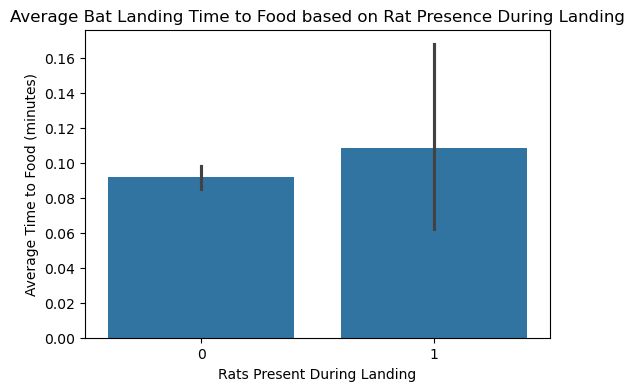

In [34]:
plt.figure(figsize=(6, 4))
sns.barplot(x='rat_present', y='bat_landing_to_food_min', data=data)
plt.title('Average Bat Landing Time to Food based on Rat Presence During Landing')
plt.xlabel('Rats Present During Landing')
plt.ylabel('Average Time to Food (minutes)')
plt.show()

C:\Users\Aseem\AppData\Local\Temp\ipykernel_12796\3256252651.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='risk', y='food_fraction', data=data, palette='viridis')


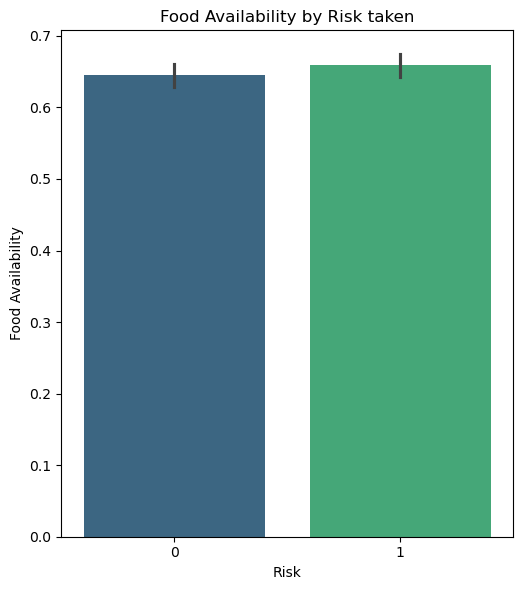

In [35]:
plt.figure(figsize=(10, 6))

# Plot availability of food per Risk taken
plt.subplot(1, 2, 1)
sns.barplot(x='risk', y='food_fraction', data=data, palette='viridis')
plt.title('Food Availability by Risk taken')
plt.xlabel('Risk')
plt.ylabel('Food Availability')

plt.tight_layout()
plt.show()

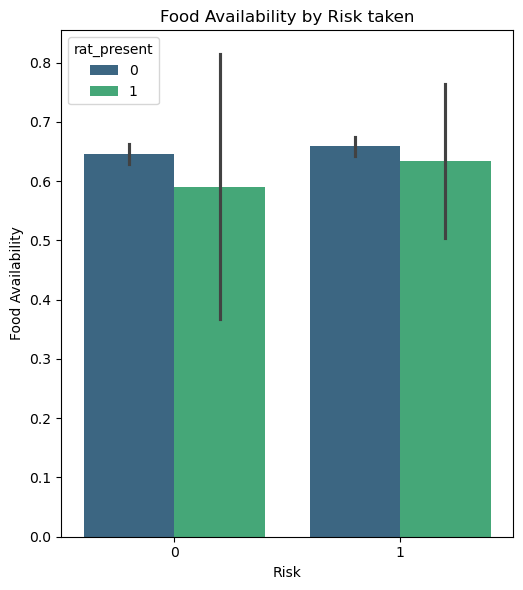

In [36]:
plt.figure(figsize=(10, 6))

# Plot availability of food per Risk taken
plt.subplot(1, 2, 1)
sns.barplot(x='risk', y='food_fraction', data=data, palette='viridis', hue='rat_present')
plt.title('Food Availability by Risk taken')
plt.xlabel('Risk')
plt.ylabel('Food Availability')
plt.tight_layout()
plt.show()